<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Data%20Preparation/Forecast_SalesPRice_with_missing_data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load one of the datasets

In [1]:
import pandas as pd

#dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_RandMissing.csv'
dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_NonRandMissing.csv'
#dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_NoMissing.csv'

try:
    df = pd.read_csv(dataset_url)
    print("Dataset loaded successfully from URL.")
except Exception as e:
    print(f"Error loading dataset from URL: {e}")
    df = None

# Display the first 5 rows of the DataFrame
if df is not None:
    print("\nFirst 5 rows of the dataset:\n\n")
    display(df.head())
    df.info()
    print("\n\nDescriptive Statistics:\n")
    display(df.describe())

Dataset loaded successfully from URL.

First 5 rows of the dataset:




,Order,MS Zoning,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
0,1,RL,1960.0,6.0,5,31770,528.0,0,3,NaN,7,215000
1,2,RH,1961.0,5.0,6,11622,730.0,0,2,NaN,5,105000
2,3,RL,1958.0,6.0,6,14267,312.0,0,3,NaN,6,172000
3,4,RL,1968.0,7.0,5,11160,522.0,0,3,2.0,8,244000
4,5,RL,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2929 entries, 0 to 2928
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order          2929 non-null   int64  
 1   MS Zoning      2929 non-null   object 
 2   Year Built     2429 non-null   float64
 3   Overall Qual   2394 non-null   float64
 4   Overall Cond   2929 non-null   int64  
 5   Lot Area       2929 non-null   int64  
 6   Garage Area    2929 non-null   float64
 7   Pool Area      2929 non-null   int64  
 8   Bedroom AbvGr  2929 non-null   int64  
 9   Full Bath      2229 non-null   float64
 10  TotRms AbvGrd  2929 non-null   int64  
 11  SalePrice      2929 non-null   int64  
dtypes: float64(4), int64(7), object(1)
memory usage: 274.7+ KB


Descriptive Statistics:



,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2929.00000,2429.000000,2394.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2229.000000,2929.000000,2929.000000
mean,1465.23660,1971.799094,6.368839,5.562991,10148.293274,472.819734,2.244111,2.854216,1.575594,6.443155,180806.263913
std,845.98674,30.148725,1.337885,1.111697,7881.337623,215.046549,35.603235,0.827868,0.548587,1.573212,79898.423323
min,1.00000,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,733.00000,1954.000000,5.000000,5.000000,7440.000000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1465.00000,1974.000000,6.000000,5.000000,9439.000000,480.000000,0.000000,3.000000,2.000000,6.000000,160000.000000
75%,2197.00000,2001.000000,7.000000,6.000000,11556.000000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2930.00000,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


### Missing Value Analysis

Now, let's analyze the missing values in the dataset. This will show us which columns have missing data and how many.

In [2]:
if df is not None:
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

    print("\nMissing values in each column:")
    # Filter to show only columns with missing values and sort them
    display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

    if missing_df['Missing Count'].sum() == 0:
        print("No missing values found in the dataset.")


Missing values in each column:


,Missing Count,Missing Percentage
Full Bath,700,23.898942
Overall Qual,535,18.265620
Year Built,500,17.070673


### Bivariate Analysis of Missing 'Full Bath' Values

Let's investigate if the missing values in the 'Full Bath' column are related to other attributes in the dataset. We'll create a new indicator column for missing 'Full Bath' and visualize its relationship with other features.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Create a boolean column indicating if 'Full Bath' is missing
    df['is_full_bath_missing'] = df['Full Bath'].isnull()
    print("Added 'is_full_bath_missing' column to the DataFrame.")
    display(df[['Full Bath', 'is_full_bath_missing']].head())
else:
    print("DataFrame 'df' is not available.")

Added 'is_full_bath_missing' column to the DataFrame.


,Full Bath,is_full_bath_missing
0,NaN,True
1,NaN,True
2,NaN,True
3,2.0,False
4,2.0,False


#### Missing 'Full Bath' by 'MS Zoning' (Categorical Feature)

We'll use a bar chart to count the number of missing 'Full Bath' values for each category within the 'MS Zoning' column.

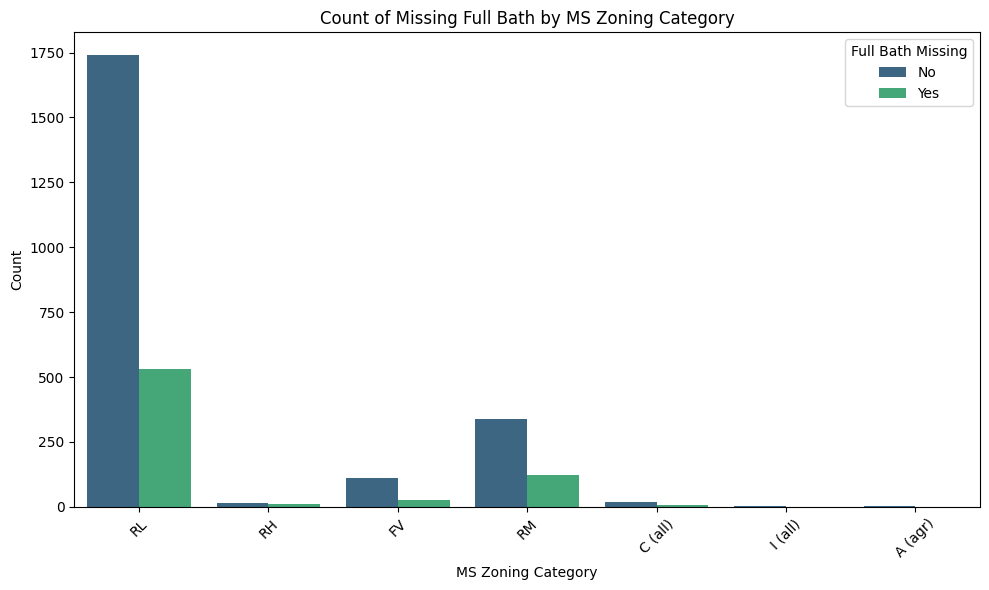

In [4]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='MS Zoning', hue='is_full_bath_missing', data=df, palette='viridis')
    plt.title('Count of Missing Full Bath by MS Zoning Category')
    plt.xlabel('MS Zoning Category')
    plt.ylabel('Count')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Full Bath' and 'Lot Area' (Numerical Feature)

For numerical features like 'Lot Area', a direct bar chart of missing counts isn't ideal. Instead, we'll visualize the distribution of 'Lot Area' for rows where 'Full Bath' is missing versus where it's present, using Kernel Density Estimate (KDE) plots. This helps us see if 'Full Bath' tends to be missing for specific 'Lot Area' ranges.

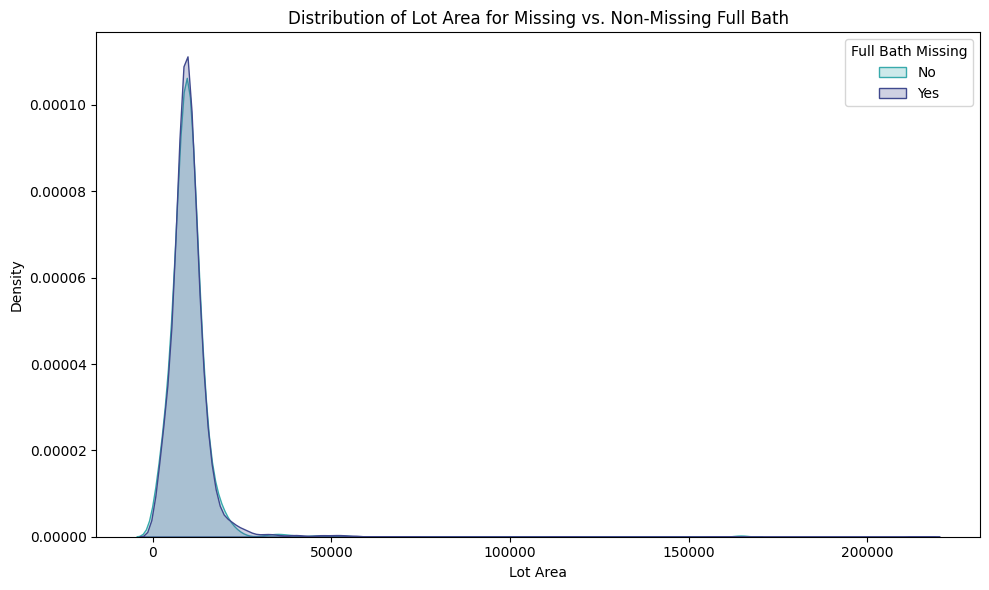

In [5]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Lot Area', hue='is_full_bath_missing', fill=True, common_norm=False, palette='mako')
    plt.title('Distribution of Lot Area for Missing vs. Non-Missing Full Bath')
    plt.xlabel('Lot Area')
    plt.ylabel('Density')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Full Bath' and 'Year Built' (Numerical Feature)

Similarly, let's look at the distribution of 'Year Built' for rows with and without missing 'Full Bath' values.

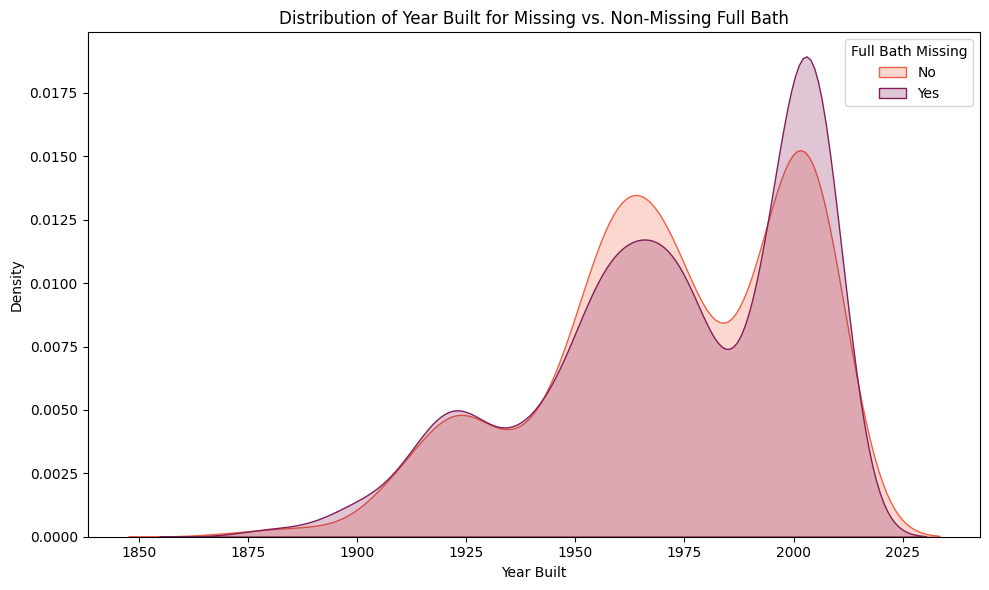

In [6]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Year Built', hue='is_full_bath_missing', fill=True, common_norm=False, palette='rocket')
    plt.title('Distribution of Year Built for Missing vs. Non-Missing Full Bath')
    plt.xlabel('Year Built')
    plt.ylabel('Density')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Overall Qual' Analysis

Let's analyze the distribution of 'Overall Qual' values and how its missingness relates to other features.

### Pearson Correlation Matrix

Let's compute the Pearson correlation matrix for the numerical attributes in the dataset to understand the relationships between them. A heatmap will be used for visualization.

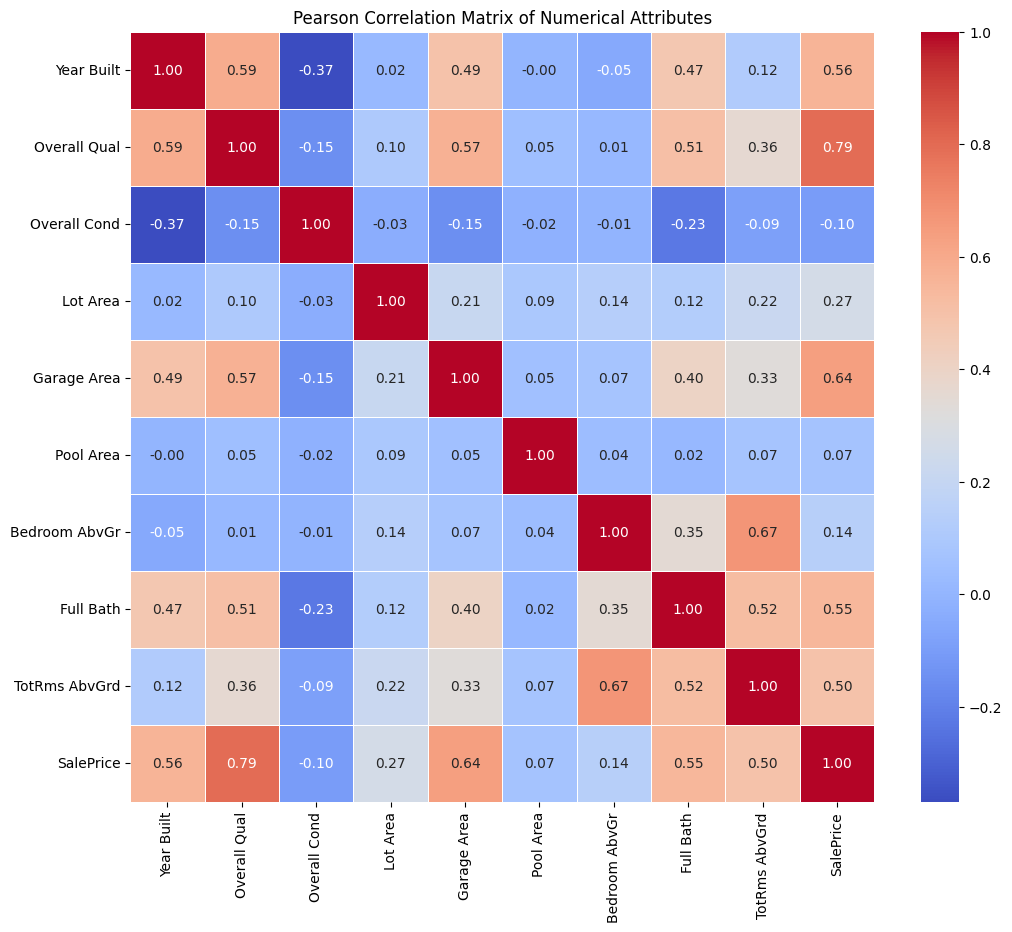

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=['int64', 'float64'])

    # Drop the 'Order' column if it exists, as it's an identifier
    if 'Order' in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=['Order'])

    # Also drop the 'is_full_bath_missing' column if it exists, as it's an indicator variable
    if 'is_full_bath_missing' in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=['is_full_bath_missing'])

    # Calculate the Pearson correlation matrix
    correlation_matrix = numerical_df.corr(method='pearson')

    # Plot the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Matrix of Numerical Attributes')
    plt.show()
else:
    print("DataFrame 'df' is not available to calculate correlation matrix.")

### Data Preprocessing for Model Training

We will begin by one-hot encoding all categorical features. Then, we will address missing numerical values using a Random Forest-based imputation method. This involves iteratively training a Random Forest model to predict missing values in one column based on the non-missing values in other columns. Finally, we will drop the `Order` and `is_full_bath_missing` columns.

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if df is not None:
    # Create a copy to avoid modifying the original DataFrame directly
    df_processed = df.copy()

    # Drop the 'is_full_bath_missing' as it's an indicator
    if 'is_full_bath_missing' in df_processed.columns:
        df_processed = df_processed.drop(columns=['is_full_bath_missing'])

    # Identify all categorical columns for one-hot encoding
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
        print(f"One-hot encoded {len(categorical_cols)} categorical columns.")
    else:
        df_encoded = df_processed
        print("No categorical columns to encode.")

    print("Shape of DataFrame after one-hot encoding:", df_encoded.shape)
    display(df_encoded.head())


One-hot encoded 1 categorical columns.
Shape of DataFrame after one-hot encoding: (2929, 17)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1,1960.0,6.0,5,31770,528.0,0,3,NaN,7,215000,False,False,False,False,True,False
1,2,1961.0,5.0,6,11622,730.0,0,2,NaN,5,105000,False,False,False,True,False,False
2,3,1958.0,6.0,6,14267,312.0,0,3,NaN,6,172000,False,False,False,False,True,False
3,4,1968.0,7.0,5,11160,522.0,0,3,2.0,8,244000,False,False,False,False,True,False
4,5,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900,False,False,False,False,True,False


In [9]:
if df_encoded is not None:
    missing_values = df_encoded.isnull().sum()
    missing_percentage = (df_encoded.isnull().sum() / len(df_encoded)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

    print("\nMissing values in each column:")
    # Filter to show only columns with missing values and sort them
    display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

    if missing_df['Missing Count'].sum() == 0:
        print("No missing values found in the dataset.")


Missing values in each column:


,Missing Count,Missing Percentage
Full Bath,700,23.898942
Overall Qual,535,18.265620
Year Built,500,17.070673


### XGBoost Regressor Training (without explicit imputation)

In [10]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_encoded' in locals() and df_encoded is not None:
    # Define features (X) and target (y) from df_encoded
    # XGBoost can handle NaNs directly, so no explicit imputation is needed here.
    X_xgb = df_encoded.drop('SalePrice', axis=1)
    y_xgb = df_encoded['SalePrice']

    # Split the data into training and testing sets
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

    print("Data split into training and testing sets for XGBoost.")
    print(f"Training features shape: {X_train_xgb.shape}")
    print(f"Testing features shape: {X_test_xgb.shape}")

    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_xgb)

    # Evaluate the model
    r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_xgb.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_encoded' is not available for XGBoost model training.")

Data split into training and testing sets for XGBoost.
Training features shape: (2343, 16)
Testing features shape: (586, 16)
XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8383
XGBoost Mean Squared Error: 1218676096.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.551533
MS Zoning_RM,0.097912
MS Zoning_RL,0.059879
Garage Area,0.046336
TotRms AbvGrd,0.045522
Lot Area,0.031617
Full Bath,0.030469
Bedroom AbvGr,0.028017
Overall Cond,0.022452
Pool Area,0.019516


### Mean Imputation on `df_encoded`

Now, let's perform mean imputation on the `df_encoded` DataFrame. This will fill any remaining `NaN` values in numerical columns with the mean of that column. The result will be stored in a new DataFrame named `df_mean`.

In [11]:
if 'df_encoded' in locals() and df_encoded is not None:
    df_mean = df_encoded.copy()

    numerical_cols = df_mean.select_dtypes(include=['int64', 'float64']).columns

    for col in numerical_cols:
        if df_mean[col].isnull().any():
            mean_value = df_mean[col].mean()
            df_mean[col] = df_mean[col].fillna(mean_value)
            print(f"Imputed missing values in '{col}' with its mean: {mean_value:.2f}")

    if df_mean.isnull().sum().sum() == 0:
        print("\nAll missing values handled in df_mean after mean imputation.")
    else:
        print("\nWarning: Some missing values still exist in df_mean. Details:")
        display(df_mean.isnull().sum()[df_mean.isnull().sum() > 0])

    print("\nShape of df_mean after mean imputation:", df_mean.shape)
    display(df_mean.describe())
else:
    print("DataFrame 'df_encoded' is not available for mean imputation.")

Imputed missing values in 'Year Built' with its mean: 1971.80
Imputed missing values in 'Overall Qual' with its mean: 6.37
Imputed missing values in 'Full Bath' with its mean: 1.58

All missing values handled in df_mean after mean imputation.

Shape of df_mean after mean imputation: (2929, 17)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2929.00000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000
mean,1465.23660,1971.799094,6.368839,5.562991,10148.293274,472.819734,2.244111,2.854216,1.575594,6.443155,180806.263913
std,845.98674,27.454134,1.209496,1.111697,7881.337623,215.046549,35.603235,0.827868,0.478540,1.573212,79898.423323
min,1.00000,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,733.00000,1958.000000,6.000000,5.000000,7440.000000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1465.00000,1971.799094,6.368839,5.000000,9439.000000,480.000000,0.000000,3.000000,1.575594,6.000000,160000.000000
75%,2197.00000,1998.000000,7.000000,6.000000,11556.000000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2930.00000,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


XGBoost Regressor Training (with Mean imputation)

In [12]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_mean' in locals() and df_mean is not None:
    # Define features (X) and target (y) from df_mean
    # XGBoost can handle NaNs directly, so no explicit imputation is needed here.
    X_xgb = df_mean.drop('SalePrice', axis=1)
    y_xgb = df_mean['SalePrice']

    # Split the data into training and testing sets
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

    print("Data split into training and testing sets for XGBoost.")
    print(f"Training features shape: {X_train_xgb.shape}")
    print(f"Testing features shape: {X_test_xgb.shape}")

    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_xgb)

    # Evaluate the model
    r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_xgb.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_rf' is not available for XGBoost model training.")

Data split into training and testing sets for XGBoost.
Training features shape: (2343, 16)
Testing features shape: (586, 16)
XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8446
XGBoost Mean Squared Error: 1170717952.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.601322
MS Zoning_RL,0.053294
Full Bath,0.053094
Garage Area,0.044164
MS Zoning_RM,0.044012
TotRms AbvGrd,0.039922
Lot Area,0.031861
MS Zoning_FV,0.024866
Bedroom AbvGr,0.022631
Overall Cond,0.022342


### Random Forest Imputation on `df_encoded`

Let's perform Random Forest imputation on the `df_encoded` DataFrame to handle its missing numerical values. The result will be stored in a new DataFrame named `df_rf`.

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if 'df_encoded' in locals() and df_encoded is not None:
    print("\nStarting Random Forest imputation for missing numerical values...")
    df_rf = df_encoded.copy()

    # Identify numerical columns with missing values
    cols_with_missing = df_rf.select_dtypes(include=['int64', 'float64']).columns[df_rf.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()

    # Exclude 'SalePrice' from imputation if it's in cols_with_missing (it's our target)
    if 'SalePrice' in cols_with_missing:
        cols_with_missing.remove('SalePrice')

    # Iterate and impute each column with missing values
    for col in cols_with_missing:
        print(f"  Imputing missing values in column: '{col}'")
        # Separate data into observed and missing for the current column
        df_observed = df_rf.dropna(subset=[col])
        df_missing = df_rf[df_rf[col].isnull()]

        if not df_missing.empty:
            # Features to train the imputer (all other columns without missing values)
            features_for_imputation = [c for c in df_observed.columns if c != col and df_observed[c].isnull().sum() == 0]

            # If there are no features to train, fall back to mean imputation for this column
            if not features_for_imputation:
                mean_val = df_observed[col].mean()
                df_rf.loc[df_rf[col].isnull(), col] = mean_val
                print(f"    (Falling back to mean imputation for '{col}' due to no clean features: {mean_val:.2f})")
                continue

            X_impute_train = df_observed[features_for_imputation]
            y_impute_train = df_observed[col]
            X_impute_predict = df_missing[features_for_imputation]

            # Handle potential missing values in features_for_imputation for X_impute_predict (shouldn't happen if selected properly)
            # If there are still missing values in the imputation features, drop those rows for prediction only.
            rows_to_drop_predict = X_impute_predict.isnull().any(axis=1)
            if rows_to_drop_predict.any():
                print(f"    Warning: Dropping {rows_to_drop_predict.sum()} rows for predicting '{col}' due to missing values in imputation features.")
                X_impute_predict = X_impute_predict[~rows_to_drop_predict]
                df_missing_subset = df_missing[~rows_to_drop_predict]
            else:
                df_missing_subset = df_missing

            if not X_impute_predict.empty:
                rf_imputer = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
                rf_imputer.fit(X_impute_train, y_impute_train)
                predicted_values = rf_imputer.predict(X_impute_predict)
                df_rf.loc[df_missing_subset.index, col] = predicted_values
                print(f"    Successfully imputed {len(predicted_values)} values for '{col}'.")
            else:
                print(f"    No rows left to predict for '{col}' after handling missing features.")
        else:
            print(f"    No missing values in '{col}' to impute.")

    # Verify no more missing values
    if df_rf.isnull().sum().sum() == 0:
        print("\nAll missing values handled after Random Forest imputation.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        display(df_rf.isnull().sum()[df_rf.isnull().sum() > 0])

    print("Shape of DataFrame after Random Forest imputation:", df_rf.shape)
    display(df_rf.describe())
else:
    print("DataFrame 'df_encoded' is not available for Random Forest imputation.")


Starting Random Forest imputation for missing numerical values...
  Imputing missing values in column: 'Year Built'
    Successfully imputed 500 values for 'Year Built'.
  Imputing missing values in column: 'Overall Qual'
    Successfully imputed 535 values for 'Overall Qual'.
  Imputing missing values in column: 'Full Bath'
    Successfully imputed 700 values for 'Full Bath'.

All missing values handled after Random Forest imputation.
Shape of DataFrame after Random Forest imputation: (2929, 17)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2929.00000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000
mean,1465.23660,1971.346589,6.177596,5.562991,10148.293274,472.819734,2.244111,2.854216,1.570584,6.443155,180806.263913
std,845.98674,29.707775,1.329105,1.111697,7881.337623,215.046549,35.603235,0.827868,0.526505,1.573212,79898.423323
min,1.00000,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,733.00000,1954.000000,5.000000,5.000000,7440.000000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1465.00000,1972.000000,6.000000,5.000000,9439.000000,480.000000,0.000000,3.000000,1.960000,6.000000,160000.000000
75%,2197.00000,2000.000000,7.000000,6.000000,11556.000000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2930.00000,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


XGBoost Regressor Training (with Random Forest imputation)

In [14]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_rf' in locals() and df_rf is not None:
    # Define features (X) and target (y) from df_rf
    # XGBoost can handle NaNs directly, so no explicit imputation is needed here.
    X_xgb = df_rf.drop('SalePrice', axis=1)
    y_xgb = df_rf['SalePrice']

    # Split the data into training and testing sets
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

    print("Data split into training and testing sets for XGBoost.")
    print(f"Training features shape: {X_train_xgb.shape}")
    print(f"Testing features shape: {X_test_xgb.shape}")

    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_xgb)

    # Evaluate the model
    r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_xgb.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_rf' is not available for XGBoost model training.")

Data split into training and testing sets for XGBoost.
Training features shape: (2343, 16)
Testing features shape: (586, 16)
XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8802
XGBoost Mean Squared Error: 902801664.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.656598
Full Bath,0.074689
MS Zoning_RM,0.049117
Lot Area,0.033090
Bedroom AbvGr,0.032167
TotRms AbvGrd,0.030674
Garage Area,0.029707
MS Zoning_RL,0.025582
MS Zoning_FV,0.017151
Overall Cond,0.014532


### K-Nearest Neighbors (KNN) Imputation on `df_encoded`

Let's perform K-Nearest Neighbors (KNN) imputation on the `df_encoded` DataFrame to handle its missing numerical values. This method imputes missing values by finding the `n_neighbors` closest samples in the training set and averaging their values. The result will be stored in a new DataFrame named `df_knn`.

In [15]:
import pandas as pd
from sklearn.impute import KNNImputer

if 'df_encoded' in locals() and df_encoded is not None:
    print("\nStarting K-Nearest Neighbors (KNN) imputation for missing numerical values...")
    df_knn = df_encoded.copy()

    # Identify numerical columns with missing values (excluding SalePrice)
    numerical_cols_with_missing = df_knn.select_dtypes(include=['int64', 'float64']).columns[
        df_knn.select_dtypes(include=['int64', 'float64']).isnull().any()
    ].tolist()

    if 'SalePrice' in numerical_cols_with_missing:
        numerical_cols_with_missing.remove('SalePrice')

    if numerical_cols_with_missing:
        # Initialize KNNImputer
        # n_neighbors is the number of neighboring samples to use for imputation
        imputer = KNNImputer(n_neighbors=5)

        # Apply imputation to the identified columns
        df_knn[numerical_cols_with_missing] = imputer.fit_transform(df_knn[numerical_cols_with_missing])
        print(f"Successfully imputed missing values in columns: {numerical_cols_with_missing}")
    else:
        print("No numerical columns with missing values to impute.")

    # Verify no more missing values (except potentially SalePrice if it was originally missing and excluded from imputation)
    if df_knn.isnull().sum().sum() == 0:
        print("\nAll missing values handled after KNN imputation.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        display(df_knn.isnull().sum()[df_knn.isnull().sum() > 0])

    print("Shape of DataFrame after KNN imputation:", df_knn.shape)
    display(df_knn.describe())
else:
    print("DataFrame 'df_encoded' is not available for KNN imputation.")


Starting K-Nearest Neighbors (KNN) imputation for missing numerical values...
Successfully imputed missing values in columns: ['Year Built', 'Overall Qual', 'Full Bath']

All missing values handled after KNN imputation.
Shape of DataFrame after KNN imputation: (2929, 17)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2929.00000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000
mean,1465.23660,1969.973840,6.281138,5.562991,10148.293274,472.819734,2.244111,2.854216,1.563952,6.443155,180806.263913
std,845.98674,30.255664,1.279328,1.111697,7881.337623,215.046549,35.603235,0.827868,0.509181,1.573212,79898.423323
min,1.00000,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,733.00000,1951.000000,5.000000,5.000000,7440.000000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1465.00000,1971.799094,6.000000,5.000000,9439.000000,480.000000,0.000000,3.000000,1.600000,6.000000,160000.000000
75%,2197.00000,1999.000000,7.000000,6.000000,11556.000000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2930.00000,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


In [16]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_knn' in locals() and df_knn is not None:
    # Define features (X) and target (y) from df_knn
    # XGBoost can handle NaNs directly, so no explicit imputation is needed here.
    X_xgb = df_knn.drop('SalePrice', axis=1)
    y_xgb = df_knn['SalePrice']

    # Split the data into training and testing sets
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

    print("Data split into training and testing sets for XGBoost.")
    print(f"Training features shape: {X_train_xgb.shape}")
    print(f"Testing features shape: {X_test_xgb.shape}")

    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_xgb)

    # Evaluate the model
    r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_xgb.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_knn' is not available for XGBoost model training.")

Data split into training and testing sets for XGBoost.
Training features shape: (2343, 16)
Testing features shape: (586, 16)
XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8521
XGBoost Mean Squared Error: 1114275328.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.530128
MS Zoning_RM,0.093113
Full Bath,0.052587
MS Zoning_RL,0.045357
Garage Area,0.042704
TotRms AbvGrd,0.038407
Lot Area,0.032680
Pool Area,0.032008
Overall Cond,0.026492
Year Built,0.025781
